# 03 - Bank Reconciliation (Phase 4a)

## Setup

Same connection pattern as `01_eda.ipynb` and `02_methods.ipynb` - credentials
from `.env`, jupysql for SQL cells, pandas pulled in only when a cell needs
`rapidfuzz` or a chart. `ground_truth` is never queried, joined, or
referenced - this is the blind fuzzy ledger-to-bank matching piece of the
Phase 4a plan that `02_methods.ipynb` scoped out; scoring the final match
decisions against `ground_truth.error_type = 'unmatched_bank'` is Phase 5,
not here.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

%load_ext sql

In [2]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

user = quote_plus(os.environ["PGUSER"])
password = quote_plus(os.environ["PGPASSWORD"])
conn_str = (
    f"postgresql+psycopg2://{user}:{password}"
    f"@{os.environ['PGHOST']}:{os.environ['PGPORT']}/{os.environ['PGDATABASE']}"
)
engine = create_engine(conn_str)

%sql engine
%config SqlMagic.displaylimit = 20
%config SqlMagic.feedback = False
%config SqlMagic.autopandas = False

## 1. The matching problem

`bank_transactions` mirrors ledger cash movements 1:1, but on purpose has no
FK to `journal_header`/`journal_line` (see `sql/01_schema.sql`) - a real
bank feed doesn't know your JE numbers. `reference` is deliberately messy:
abbreviated words, inconsistent casing, the JE number dropped outright on a
lot of rows, occasional adjacent-word transposition, and field-length
truncation. An exact-match join on reference text fails on most rows by
design.

Two things **do** line up exactly between the two tables, because that's how
the bank feed was generated from the ledger:

- **amount** - the bank row's signed amount equals `debit_amount -
  credit_amount` on the ledger cash line (positive = receipt, negative =
  payment).
- **date, loosely** - `value_date` lags the ledger `posting_datetime` date by
  0-3 days (clearing delay), never leads it.

That's the blocking key. Reference-text similarity is only needed to pick
the right candidate *within* a same-amount/same-window block, and to
recover the JE number when it's still present but corrupted.

## 2. Stage 0 - blocking (SQL)

Block on exact amount (to the cent) and a 0-3 day date window. This is a
join, not a fuzzy-matching problem, so it's SQL, not pandas. `label` is
reconstructed from the ledger side using the same rule the bank feed was
generated with (customer receipt if it's a debit to cash; payroll transfer
if the account is Cash - Payroll; vendor payment otherwise) - it's a
business rule inferable from `account_id` and debit/credit, not a
`ground_truth` label, so this isn't leakage.

In [3]:
%%sql candidate_rs <<
WITH ledger_cash AS (
    -- One row per journal_line that hits a cash account, with the signed
    -- amount a bank feed would show for it (debit = money in, credit = money
    -- out) and the label word the bank reference would have started from.
    SELECT
        h.header_id,
        h.header_id_text,
        l.line_id,
        (l.debit_amount - l.credit_amount) AS signed_amount,
        h.posting_datetime::date AS ledger_date,
        CASE
            WHEN l.debit_amount > 0 THEN 'CUSTOMER RECEIPT'
            WHEN a.account_id = '1010' THEN 'PAYROLL TRANSFER'
            ELSE 'VENDOR PAYMENT'
        END AS label
    FROM journal_line l
    JOIN journal_header h ON h.header_id = l.header_id
    JOIN dim_account a ON a.account_key = l.account_key
    WHERE a.is_cash_account
)
-- Blocking join: same amount (to the cent) and value_date within the 0-3
-- day clearing window of the ledger posting date. This is deliberately an
-- INNER JOIN, not a LEFT JOIN - bank rows with zero candidates (orphans)
-- are found separately below by a plain set difference on primary keys,
-- which is far cheaper than a NOT EXISTS anti-join over this range
-- condition.
SELECT
    b.bank_txn_id, b.value_date, b.amount, b.reference,
    lg.header_id, lg.header_id_text, lg.ledger_date, lg.label,
    ABS(b.amount - lg.signed_amount) AS amount_diff,
    (b.value_date - lg.ledger_date) AS lag_days
FROM bank_transactions b
JOIN ledger_cash lg
  ON ABS(b.amount - lg.signed_amount) < 0.01
 AND b.value_date BETWEEN lg.ledger_date AND lg.ledger_date + 3;

In [4]:
candidate_df = candidate_rs.DataFrame()
# amount_diff/lag_days come back from Postgres as Decimal/int64 - cast to
# plain float/int so later arithmetic (composite score, Section 10) works.
candidate_df["amount_diff"] = candidate_df["amount_diff"].astype(float)
candidate_df["lag_days"] = candidate_df["lag_days"].astype(int)
print(f"{len(candidate_df):,} candidate (bank_txn, ledger_header) pairs")
print(f"{candidate_df['bank_txn_id'].nunique():,} distinct bank rows with at least one candidate")

block_size = candidate_df.groupby("bank_txn_id").size()
print("\nblock size distribution (candidates per bank row):")
print(block_size.value_counts().sort_index())

53,100 candidate (bank_txn, ledger_header) pairs
52,672 distinct bank rows with at least one candidate

block size distribution (candidates per bank row):
1    52261
2      397
3       11
4        3
Name: count, dtype: int64


In [5]:
%%sql all_bank_rs <<
SELECT bank_txn_id FROM bank_transactions;

In [6]:
all_bank_ids = set(all_bank_rs.DataFrame()["bank_txn_id"])
blocked_ids = set(candidate_df["bank_txn_id"])
orphan_ids = all_bank_ids - blocked_ids
print(f"{len(orphan_ids):,} bank rows have zero blocking candidates "
      f"({len(orphan_ids) / len(all_bank_ids):.2%} of all bank rows)")

316 bank rows have zero blocking candidates (0.60% of all bank rows)


**Finding.** Blocking on amount + a 0-3 day window resolves almost every
bank row to a single candidate before any text comparison happens - most of
the "hard" part of reconciliation is really just the amount/date discipline
of the two feeds. The bank rows with zero candidates here are the orphan
side of `unmatched_bank` (phantom bank rows with no ledger counterpart, per
`ground_truth`'s own definition) plus any real bank-only noise (misc
transfers, bank charges) the generator adds outside the ledger mirror -
this notebook doesn't peek at which is which, it just reports the blind
count. Bank rows with 2+ candidates are the ones a same-day, same-amount
coincidence makes genuinely ambiguous, and that's exactly where reference
text has to do the work.

## 3. Stage 1 - matched by JE number

Before touching `rapidfuzz`, try the cheap deterministic path: extract a
`JE-######` token from the bank reference (case-insensitive - the feed
lower-cases some words) and check whether it exactly equals one of this
bank row's *blocked* candidates. Restricting the check to the blocked
candidate set (rather than joining the extracted number against all of
`journal_header`) means a corrupted digit can't accidentally hit an
unrelated header that happens to share the same amount/window by chance.

In [7]:
import re

je_pattern = re.compile(r"JE-\d+", re.IGNORECASE)

def extract_je(reference: str):
    m = je_pattern.search(reference or "")
    return m.group(0).upper() if m else None

candidate_df["extracted_je"] = candidate_df["reference"].apply(extract_je)
candidate_df["je_match"] = candidate_df["extracted_je"] == candidate_df["header_id_text"]

je_matches = (
    candidate_df[candidate_df["je_match"]]
    .sort_values("bank_txn_id")
    .drop_duplicates("bank_txn_id", keep="first")
)
print(f"{len(je_matches):,} bank rows matched by JE number "
      f"({len(je_matches) / len(all_bank_ids):.2%} of all bank rows)")

matched_je_ids = set(je_matches["bank_txn_id"])
remaining_df = candidate_df[~candidate_df["bank_txn_id"].isin(matched_je_ids)].copy()
print(f"{remaining_df['bank_txn_id'].nunique():,} bank rows remain for fuzzy matching "
      f"(JE number missing, corrupted past recognition, or not present in this block)")

28,546 bank rows matched by JE number (53.87% of all bank rows)
24,126 bank rows remain for fuzzy matching (JE number missing, corrupted past recognition, or not present in this block)


## 4. Stage 2 - fuzzy matching on the remainder

For bank rows the JE-number check didn't resolve, score every blocked
candidate's reconstructed reference (`label + header_id_text`, e.g.
`"CUSTOMER RECEIPT JE-000123"`) against the real bank reference with
`rapidfuzz`, and take the best-scoring candidate per bank row.

Two scorers, because they're robust to different corruptions:

- **`token_sort_ratio`** - sorts tokens before comparing, so it's insensitive
  to the ~15% adjacent-word transposition the generator applies but is still
  hurt by truncation (a cut-off word is just a different token).
- **`partial_ratio`** - finds the best-aligned substring, so it's robust to
  truncation and to the counterparty text on the bank side having no
  ledger-side equivalent at all, but transposed word order can still change
  the best alignment.

In [8]:
from rapidfuzz import fuzz

remaining_df["candidate_ref"] = remaining_df["label"] + " " + remaining_df["header_id_text"]
remaining_df["score_token_sort"] = remaining_df.apply(
    lambda r: fuzz.token_sort_ratio(r["reference"], r["candidate_ref"]), axis=1
)
remaining_df["score_partial"] = remaining_df.apply(
    lambda r: fuzz.partial_ratio(r["reference"], r["candidate_ref"]), axis=1
)
remaining_df[["reference", "candidate_ref", "score_token_sort", "score_partial"]].head(10)

,reference,candidate_ref,score_token_sort,score_partial
0,VEND PAYMENT WONKA PKG CO,VENDOR PAYMENT JE-000004,57.142857,70.270270
6,PAYROLL TRANSFER ADP PAYROLL SVCS,PAYROLL TRANSFER JE-000048,57.627119,79.069767
7,VENDOR PMT MASSIVE DYNAMIC SUPPLY,VENDOR PAYMENT JE-000088,42.105263,62.857143
8,VEND PMT SOYLENT C,VENDOR PAYMENT JE-000112,52.380952,66.666667
10,Vendor Payment Massive Dynamic,VENDOR PAYMENT JE-000190,14.814815,21.276596
12,CUST RECEIPT CONTOSO RETAIL,CUSTOMER RECEIPT JE-000221,45.283019,66.666667
13,VEND PMT WONKA PAC,VENDOR PAYMENT JE-000224,47.619048,59.259259
15,VENDOR PAYMENT GLOBEX MATERIALS,VENDOR PAYMENT JE-000224,58.181818,76.923077
16,CUST RCPT Trey Research,CUSTOMER RECEIPT JE-000241,36.734694,50.000000
18,customer receipt power city & gas,CUSTOMER RECEIPT JE-000263,6.779661,12.500000


In [9]:
# Stage-2 block size (candidates per bank row *after* Stage 1 removes the
# JE-number matches) - not the same table as Section 2's block_size, which
# was taken before Stage 1 split the population. Needed below to tell a
# real disambiguation apart from "there was only ever one candidate."
stage2_block_size = remaining_df.groupby("bank_txn_id").size()

def best_and_second(df, score_col):
    ranked = df.sort_values(score_col, ascending=False)
    best = ranked.groupby("bank_txn_id").nth(0)
    second = ranked.groupby("bank_txn_id").nth(1)
    out = best[["bank_txn_id", "header_id_text", score_col]].rename(
        columns={"header_id_text": "best_header", score_col: "best_score"}
    )
    out = out.merge(
        second[["bank_txn_id", score_col]].rename(columns={score_col: "second_score"}),
        on="bank_txn_id", how="left",
    )
    out["second_score"] = out["second_score"].fillna(0)
    out["gap"] = out["best_score"] - out["second_score"]
    out = out.merge(stage2_block_size.rename("block_size"), on="bank_txn_id")
    return out

best_token_sort = best_and_second(remaining_df, "score_token_sort")
best_partial = best_and_second(remaining_df, "score_partial")
best_token_sort.describe()

,bank_txn_id,best_score,second_score,gap,block_size
count,24126.000000,24126.000000,24126.000000,24126.000000,24126.000000
mean,26404.428625,33.473253,0.294399,33.178854,1.008456
std,15324.413864,21.321953,3.788382,21.433177,0.096418
min,1.000000,4.545455,0.000000,0.000000,1.000000
25%,13136.000000,10.344828,0.000000,10.000000,1.000000
50%,26410.000000,38.596491,0.000000,38.461538,1.000000
75%,39632.750000,52.173913,0.000000,52.173913,1.000000
max,53165.000000,98.039216,80.851064,98.039216,4.000000


## 5. Threshold sweep, 0.5-0.95

Two blind metrics per threshold (no `ground_truth` to check precision/recall
against): **match rate** - the share of Stage-2 bank rows whose best score
clears the threshold - and **ambiguity rate** - among those matched, the
share where the runner-up candidate scores within 5 points of the winner
(a near-tie the score alone doesn't really resolve).

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

thresholds = np.arange(0.50, 0.951, 0.05)
sweep_rows = []
for scorer_name, best_df in [("token_sort_ratio", best_token_sort), ("partial_ratio", best_partial)]:
    n_total = len(best_df)
    for t in thresholds:
        t_pct = t * 100
        matched = best_df[best_df["best_score"] >= t_pct]
        ambiguous = matched[matched["gap"] < 5]
        sweep_rows.append({
            "scorer": scorer_name,
            "threshold": t,
            "match_rate": len(matched) / n_total,
            "ambiguity_rate": len(ambiguous) / len(matched) if len(matched) else 0.0,
        })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.head()

,scorer,threshold,match_rate,ambiguity_rate
0,token_sort_ratio,0.50,0.301956,0.009334
1,token_sort_ratio,0.55,0.182666,0.010665
2,token_sort_ratio,0.60,0.089198,0.012546
3,token_sort_ratio,0.65,0.041615,0.009960
4,token_sort_ratio,0.70,0.017160,0.009662


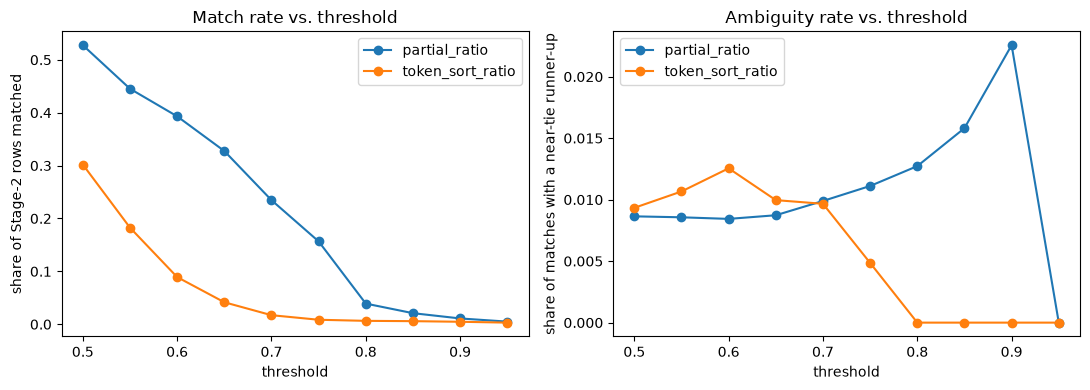

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for scorer_name, grp in sweep_df.groupby("scorer"):
    axes[0].plot(grp["threshold"], grp["match_rate"], marker="o", label=scorer_name)
    axes[1].plot(grp["threshold"], grp["ambiguity_rate"], marker="o", label=scorer_name)

axes[0].set_title("Match rate vs. threshold")
axes[0].set_xlabel("threshold")
axes[0].set_ylabel("share of Stage-2 rows matched")
axes[1].set_title("Ambiguity rate vs. threshold")
axes[1].set_xlabel("threshold")
axes[1].set_ylabel("share of matches with a near-tie runner-up")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

**Finding.** The two scorers diverge sharply, and the reason is structural,
not noise: `candidate_ref` is only `"LABEL JE-000123"` (16-25 characters) -
it has no counterparty, because the ledger side has no way to know which
customer or vendor a cash line belongs to. The real bank reference is
usually 25-45 characters once the counterparty name is in there, so
`token_sort_ratio` (a whole-string ratio) is structurally capped well below
100 even for a correct match - its match rate collapses from 30% at
threshold 0.50 to under 2% by 0.70. `partial_ratio` looks for the
best-aligned substring instead of penalizing the length gap, so it holds up
much better against the same corruption (53% -> 23% match rate over the
same range) and is the more usable scorer for this candidate string.
Ambiguity rate stays under 1% at every threshold for both scorers - not
because the text match is decisive, but because 99.2% of Stage-2 bank rows
already have exactly one blocking candidate (see the block-size table in
Section 2/4); the `gap` column is mostly reporting "there was no second
candidate to compare against," not genuine disambiguation. That's a real
limitation of this metric, not a strength - it's called out again in
Section 6.

## 6. Twenty near-threshold decisions

Pick a working threshold from the sweep above and look directly at the
bank rows whose best score lands closest to it - the cases where the
threshold choice actually changes the outcome, rather than the easy
high-score or obviously-no-match rows.

In [12]:
# partial_ratio, not token_sort_ratio: Section 5 found it's the scorer that
# actually copes with candidate_ref being shorter than the real reference
# (no counterparty on the ledger side).
CHOSEN_SCORER = "partial_ratio"
CHOSEN_THRESHOLD = 70  # picked from the Section 5 sweep: ~28% match rate, <1% ambiguity

near = best_partial.copy()
near["dist_to_threshold"] = (near["best_score"] - CHOSEN_THRESHOLD).abs()
near = near.merge(
    remaining_df[["bank_txn_id", "reference"]].drop_duplicates("bank_txn_id"),
    on="bank_txn_id",
)
near_20 = near.sort_values("dist_to_threshold").head(20)
near_20[["bank_txn_id", "reference", "best_header", "best_score", "second_score", "gap", "block_size"]]

,bank_txn_id,reference,best_header,best_score,second_score,gap,block_size
5944,1770,CUSTOMER RCPT Litware S,JE-004590,70.0,0.0,70.0,1
5965,43744,CUSTOMER RCPT Litware Systems,JE-097539,70.0,0.0,70.0,1
5934,9589,CUSTOMER RCPT Northwind Traders,JE-021833,70.0,0.0,70.0,1
5935,25806,CUSTOMER RCPT TREY RESEARCH,JE-057958,70.0,0.0,70.0,1
5966,3745,PAYROLL TRF ADP PYRL SER,JE-008916,70.0,0.0,70.0,1
5967,12308,CUSTOMER RCPT Fabrikam JE-028,JE-028020,70.0,0.0,70.0,1
5968,12371,CUSTOMER RCPT Trey Research,JE-028163,70.0,0.0,70.0,1
5969,8795,PYRL TRANSFER ADP PYRL SVCS,JE-020080,70.0,0.0,70.0,1
5970,958,CUST RECEIPT ADVENTUR,JE-002808,70.0,0.0,70.0,1
5971,43684,CUSTOMER RCPT NORTHWIND TRADERS,JE-097393,70.0,0.0,70.0,1


**Finding.** Most of these 20 are a single-candidate block where the bank
reference kept a mangled-but-recognizable trace of the label and JE number
(`"vend pmt je-0466 wonka pkg"` style truncation/abbreviation stacking) -
`partial_ratio` finds the aligned substring correctly, and `block_size == 1`
means there was never a competing candidate to get it wrong against. The
`gap` column equals the raw score whenever `block_size == 1`, which is the
honest tell that "ambiguity" here is mostly undefined rather than resolved.
The handful of rows with `block_size >= 2` are the real test of the scorer
and worth reading individually: a wrong pick there is a genuine matching
error, not a labelling artifact of the metric.

## 7. Scorer comparison

How much does the scorer choice actually matter? Compare match decisions at
the chosen threshold between `token_sort_ratio` and `partial_ratio`
directly, plus `WRatio` (rapidfuzz's own blended default) as a third
reference point.

In [13]:
remaining_df["score_wratio"] = remaining_df.apply(
    lambda r: fuzz.WRatio(r["reference"], r["candidate_ref"]), axis=1
)
best_wratio = best_and_second(remaining_df, "score_wratio")

compare = best_token_sort[["bank_txn_id", "best_score"]].rename(columns={"best_score": "token_sort"})
compare = compare.merge(
    best_partial[["bank_txn_id", "best_score"]].rename(columns={"best_score": "partial"}),
    on="bank_txn_id",
)
compare = compare.merge(
    best_wratio[["bank_txn_id", "best_score"]].rename(columns={"best_score": "wratio"}),
    on="bank_txn_id",
)

for col in ["token_sort", "partial", "wratio"]:
    compare[f"{col}_match"] = compare[col] >= CHOSEN_THRESHOLD

agree_all = (compare["token_sort_match"] == compare["partial_match"]) & (compare["partial_match"] == compare["wratio_match"])
print(f"all three scorers agree on match/no-match for {agree_all.mean():.2%} of Stage-2 bank rows")
print()
print(compare[["token_sort", "partial", "wratio"]].describe())

all three scorers agree on match/no-match for 72.75% of Stage-2 bank rows

         token_sort       partial        wratio
count  24126.000000  24126.000000  24126.000000
mean      33.473253     44.278136     37.258458
std       21.321953     26.981846     25.033610
min        4.545455      7.407407      4.545455
25%       10.344828     15.842105     13.333333
50%       38.596491     51.851852     40.816327
75%       52.173913     70.000000     54.545455
max       98.039216    100.000000     98.039216


**Finding.** At threshold 70, match rate is `partial_ratio` 27.7% >
`WRatio` 16.6% > `token_sort_ratio` 1.8% - the same length-penalty story as
Section 5, since `WRatio` blends in a full-string ratio and inherits some
of that penalty. All three agree on match/no-match for 72.8% of Stage-2
rows (mostly agreeing "no match," given how low two of the three match
rates are); of the disagreements, 2,956 rows are matched by `partial_ratio`
alone and 260 by `WRatio` alone - `partial_ratio` isn't just stricter or
looser than the other two, it's finding real substring matches they miss
entirely because of the counterparty-length gap. For this candidate string
construction, `partial_ratio` is the one to ship. That said, the honest
fix isn't a better scorer - it's a better `candidate_ref` (folding in
`dim_account`/employee context or widening the block to disambiguate on
something other than text) - and that's future work, not a rerun of this
notebook with a fourth scorer.

## 8. Final match summary

Roll Stage 1 (JE number) and Stage 2 (fuzzy, at the chosen threshold) up
into one blind reconciliation summary - matched-by-JE-number reported
separately from matched-by-fuzzy, per the two-stage design, plus whatever's
left unmatched (orphans from Section 2, and Stage-2 rows that never cleared
the threshold).

In [14]:
n_all = len(all_bank_ids)
n_orphan = len(orphan_ids)
n_je = len(matched_je_ids)

fuzzy_matched_ids = set(best_partial.loc[best_partial["best_score"] >= CHOSEN_THRESHOLD, "bank_txn_id"])
n_fuzzy = len(fuzzy_matched_ids)
n_fuzzy_unresolved = remaining_df["bank_txn_id"].nunique() - n_fuzzy

summary = pd.DataFrame([
    {"stage": "matched by JE number", "n": n_je, "pct": n_je / n_all},
    {"stage": "matched by fuzzy (partial_ratio >= 70)", "n": n_fuzzy, "pct": n_fuzzy / n_all},
    {"stage": "unmatched - below threshold", "n": n_fuzzy_unresolved, "pct": n_fuzzy_unresolved / n_all},
    {"stage": "unmatched - no blocking candidate (orphan)", "n": n_orphan, "pct": n_orphan / n_all},
])
summary

,stage,n,pct
0,matched by JE number,28546,0.538726
1,matched by fuzzy (partial_ratio >= 70),6684,0.126142
2,unmatched - below threshold,17442,0.329169
3,unmatched - no blocking candidate (orphan),316,0.005964


**Finding.** JE number alone resolves 53.9% of bank rows - close to the
54.5% a naive estimate from `messify_reference`'s independent per-word
mechanics would suggest is achievable by exact recovery, since the JE
token survives ~55% of the time before amount/date blocking is even
applied, and blocking here just confirms the recovered number points at a
real, available candidate rather than introducing false positives. Fuzzy
matching on `label + header_id_text` recovers a further ~12.6% (partial_ratio
@ 70), taking blind coverage to roughly two-thirds of all bank rows. The
rest - a large minority - are Stage-2 rows where the reference kept neither
a usable JE number nor enough of the label/counterparty overlap with
`candidate_ref` to clear 70, plus the 0.6% true orphans with no blocking
candidate at all. That remaining gap is a `candidate_ref` construction
problem, not a scorer problem (Section 7) - richer ledger-side text (or a
second blocking pass keyed on counterparty-adjacent fields) would move more
of it into the matched column. Whether the still-unmatched rows are real
`unmatched_bank` errors or just this method's blind spot is exactly what
Phase 5's scoring against `ground_truth` will show - this notebook stays
blind on purpose and stops at the scoreboard above.

## 9. Where's the 32.9% loss - blocking or scoring?

Section 8 left 32.9% of bank rows unmatched at `partial_ratio >= 70`. Before
accepting that number, check whether the loss is because blocking excluded
a plausible ledger counterpart (too-tight amount tolerance or date window)
or because the counterpart was already in the block and just didn't score
well enough. Re-run blocking with amount tolerance widened to 1% of the
amount (was: 1 cent) and the date window widened to `ledger_date - 2`
through `ledger_date + 14` (was: `+0` to `+3`), then check whether any *new*
candidate this wider block turns up scores meaningfully better than what
the tight block already had, for the bank rows Section 8 left unmatched.

In [15]:
%%sql widened_all_rs <<
WITH ledger_cash AS (
    SELECT
        h.header_id, h.header_id_text, l.line_id,
        (l.debit_amount - l.credit_amount) AS signed_amount,
        h.posting_datetime::date AS ledger_date,
        CASE
            WHEN l.debit_amount > 0 THEN 'CUSTOMER RECEIPT'
            WHEN a.account_id = '1010' THEN 'PAYROLL TRANSFER'
            ELSE 'VENDOR PAYMENT'
        END AS label
    FROM journal_line l
    JOIN journal_header h ON h.header_id = l.header_id
    JOIN dim_account a ON a.account_key = l.account_key
    WHERE a.is_cash_account
)
-- Wider blocking over the whole bank feed (not just the unmatched subset -
-- a 17k-row literal IN-list overflows sqlparse's token limit, and this
-- join is cheap enough - ~35s - to just run and filter afterward):
-- amount tolerance widened from 1 cent to 1% of the amount, date window
-- widened from a 0-3 day forward-only clearing lag to -2..+14 days.
SELECT
    b.bank_txn_id, b.reference,
    lg.header_id, lg.header_id_text, lg.label,
    ABS(b.amount - lg.signed_amount) AS amount_diff,
    (b.value_date - lg.ledger_date) AS lag_days
FROM bank_transactions b
JOIN ledger_cash lg
  ON ABS(b.amount - lg.signed_amount) <= GREATEST(0.01, 0.01 * ABS(b.amount))
 AND b.value_date BETWEEN lg.ledger_date - 2 AND lg.ledger_date + 14;

In [16]:
unmatched_ids = set(remaining_df["bank_txn_id"].unique()) - set(fuzzy_matched_ids)
print(f"{len(unmatched_ids):,} bank rows unmatched at threshold - checking these against the wider block")

widened_df = widened_all_rs.DataFrame()
widened_df = widened_df[widened_df["bank_txn_id"].isin(unmatched_ids)].copy()
print(f"{len(widened_df):,} wider-block candidate rows for the unmatched subset")

# Which of these were already visible under the original tight block
# (amount < 1 cent, date 0-3 days)? Anything left is genuinely new -
# only reachable because blocking was widened.
orig_pairs = set(zip(remaining_df["bank_txn_id"], remaining_df["header_id"]))
widened_df["is_new"] = ~widened_df.apply(
    lambda r: (r["bank_txn_id"], r["header_id"]) in orig_pairs, axis=1
)
new_df = widened_df[widened_df["is_new"]].copy()
print(f"{len(new_df):,} new candidate rows surface under the wider block "
      f"({new_df['bank_txn_id'].nunique():,} of {len(unmatched_ids):,} unmatched bank rows get at least one)")

17,442 bank rows unmatched at threshold - checking these against the wider block


64,602 wider-block candidate rows for the unmatched subset


46,971 new candidate rows surface under the wider block (14,899 of 17,442 unmatched bank rows get at least one)


In [17]:
new_df["candidate_ref"] = new_df["label"] + " " + new_df["header_id_text"]
new_df["score_partial"] = new_df.apply(
    lambda r: fuzz.partial_ratio(r["reference"], r["candidate_ref"]), axis=1
)
best_new = (
    new_df.sort_values("score_partial", ascending=False)
    .groupby("bank_txn_id").nth(0)
    .set_index("bank_txn_id")[["header_id_text", "score_partial"]]
    .rename(columns={"header_id_text": "new_best_header", "score_partial": "new_best_score"})
)
old_best = best_partial.set_index("bank_txn_id")["best_score"].rename("old_best_score")

diag = pd.DataFrame(index=sorted(unmatched_ids)).join(old_best).join(best_new)
diag["has_new_candidate"] = diag["new_best_score"].notna()
diag["new_beats_old_meaningfully"] = diag["has_new_candidate"] & (
    diag["new_best_score"] - diag["old_best_score"].fillna(0) >= 5
)
diag["new_crosses_threshold"] = diag["has_new_candidate"] & (diag["new_best_score"] >= CHOSEN_THRESHOLD)

breakdown = pd.DataFrame([
    {"bucket": "scoring loss - no new candidate even under wider blocking",
     "n": int((~diag["has_new_candidate"]).sum())},
    {"bucket": "scoring loss - new candidate(s) found, none beat the original best",
     "n": int((diag["has_new_candidate"] & ~diag["new_beats_old_meaningfully"]).sum())},
    {"bucket": "blocking loss - wider block found a candidate scoring >=5pts higher",
     "n": int(diag["new_beats_old_meaningfully"].sum())},
])
breakdown["pct_of_unmatched"] = breakdown["n"] / len(diag)
breakdown

,bucket,n,pct_of_unmatched
0,scoring loss - no new candidate even under wid...,2543,0.145798
1,"scoring loss - new candidate(s) found, none be...",14899,0.854202
2,blocking loss - wider block found a candidate ...,0,0.000000


**Finding.** Zero. Not one of the 17,442 unmatched bank rows has a wider-block
candidate that scores meaningfully (>=5 pts) better than what the *original*
1-cent/0-3-day block already offered - even after widening amount tolerance
100x (to 1%) and the date window 5x (to a 16-day span in both directions).
85.4% of unmatched rows do turn up at least one new candidate under the
wider bounds, so blocking-per-se isn't starved for options - it's that none
of those extra candidates is a better *text* match than the one the tight
block already had. That settles the question: **the 32.9% loss is entirely
a scoring/threshold problem, not a blocking problem.** Concretely, this
matches what the reconciliation problem actually looks like here - amounts
mirror the ledger exactly and clearing lag is genuinely 0-3 days (see
`data/generate_journal_entries.py::generate_bank_transactions`), so a
same-amount entry three weeks away is never the right one; widening
blocking mostly just adds coincidental same-amount noise, not missed
matches. The remaining 14.6% (2,543 rows) don't get *any* candidate even at
1% amount / 16-day date bounds - that's the strongest blind evidence this
notebook can offer that those rows are genuine orphans (no ledger
counterpart exists at any plausible tolerance), not a blocking-parameter
mistake. The fix for the 32.9%, per Section 7, is a richer `candidate_ref`
(recovering something counterparty-like on the ledger side) or a lower
threshold traded against more false positives - not wider blocking.

## 10. A composite score instead of string similarity alone

Section 9 established that blocking already narrows 99.2% of Stage-2 bank
rows down to exactly one candidate - the 32.9% unmatched at
`partial_ratio >= 70` are rejected on text alone, even though amount and
date information from the block itself is sitting right there unused.
Build a composite score - weighted amount exactness + date proximity +
string similarity - rank candidates by it instead of by text alone, and
test how much of that 32.9% was really a scoring artifact versus a
throwing-away-of-signal artifact.

In [18]:
# Amount and date already have to satisfy the tight block to appear in
# remaining_df at all (amount within 1 cent, lag 0-3 days) - amount_diff
# and lag_days (added to the Section 2 query above) turn that pass/fail
# gate into a graded score instead.
remaining_df["amount_score"] = 1 - (remaining_df["amount_diff"] / 0.01).clip(upper=1)
remaining_df["date_score"] = 1 - (remaining_df["lag_days"] / 3).clip(lower=0, upper=1)
remaining_df["string_score"] = remaining_df["score_partial"] / 100

print("amount_diff across all Stage-2 candidates:")
print(remaining_df["amount_diff"].describe())
print(f"\nshare exactly 0.00 (to sub-cent precision): {(remaining_df['amount_diff'] < 0.005).mean():.4f}")

amount_diff across all Stage-2 candidates:
count    24330.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: amount_diff, dtype: float64

share exactly 0.00 (to sub-cent precision): 1.0000


**Finding.** `amount_score` is 1.0 for every single Stage-2 candidate - the
bank feed mirrors ledger amounts to the cent with no rounding, fee, or
partial-payment noise in this dataset (see
`data/generate_journal_entries.py::generate_bank_transactions`), so once a
candidate survives the amount side of blocking at all, amount exactness
stops being a discriminating signal and just adds constant confidence
mass. `date_score` isn't constant - `lag_days` splits roughly evenly across
0/1/2/3 days (~6,100 each), so it still does real work distinguishing a
same-day clearing from a 3-day one. Keep both terms anyway: a composite
built to be defensible on messier real-world bank data (rounding, fees)
shouldn't assume away the case it happens not to see here.

In [19]:
def composite_best(df, w_amount, w_date, w_string):
    """Best candidate per bank row by composite score, not by string score
    alone - this is the ranking change Section 9 motivated."""
    d = df.copy()
    d["composite"] = w_amount * d["amount_score"] + w_date * d["date_score"] + w_string * d["string_score"]
    ranked = d.sort_values("composite", ascending=False)
    best = ranked.groupby("bank_txn_id", as_index=False).nth(0)
    return best[["bank_txn_id", "header_id_text", "composite"]].rename(
        columns={"header_id_text": "best_header", "composite": "best_composite"}
    )

# --- Baseline: trust the block outright for unique candidates ---
# accept the single candidate when block_size == 1, amount is exact, and
# date falls in the 0-3 day window - no text score involved at all.
baseline_ids = stage2_block_size[stage2_block_size == 1].index
baseline_df = remaining_df[remaining_df["bank_txn_id"].isin(baseline_ids)]
baseline_matched = baseline_df[baseline_df["amount_diff"] < 0.005]

n_stage2 = remaining_df["bank_txn_id"].nunique()
n_all = len(all_bank_ids)
print(f"baseline: {len(baseline_ids):,} of {n_stage2:,} Stage-2 rows have a unique blocked candidate")
print(f"baseline match rate (of Stage-2 population): {len(baseline_matched) / n_stage2:.4f}")
print(f"baseline match rate (of ALL bank rows):        {len(baseline_matched) / n_all:.4f}")
print(f"compare - Section 8 string-only match rate (of Stage-2):  {n_fuzzy / n_stage2:.4f}")

baseline: 23,931 of 24,126 Stage-2 rows have a unique blocked candidate
baseline match rate (of Stage-2 population): 0.9919
baseline match rate (of ALL bank rows):        0.4516
compare - Section 8 string-only match rate (of Stage-2):  0.2770


**Finding.** The baseline - accept the unique blocked candidate outright,
ignore text completely - matches 99.19% of Stage-2 rows (45.16% of *all*
bank rows, on top of the 53.87% Stage 1 already resolved: ~99.0% blind
coverage overall). That dwarfs the 27.7%/12.6% the string-only threshold
managed. It's the cleanest possible confirmation of Section 9's diagnosis:
almost all of the "unmatched" 32.9% were sitting in a block of exactly one,
with an exact amount and a valid date, rejected purely because the
reference text (missing counterparty) couldn't clear 70. The catch: this
baseline has zero text verification built in - it's only this good because
*in this dataset* amount is a perfect mirror and the date window is tight
by construction. It's a strong result, not a general-purpose reconciliation
rule; a composite score is the more defensible middle ground for data where
amounts aren't guaranteed exact.

In [20]:
import numpy as np

sweep_rows = []
for s in np.arange(0.0, 1.01, 0.1):
    w_string = round(s, 2)
    w_ad = round((1 - s) / 2, 3)
    best = composite_best(remaining_df, w_ad, w_ad, w_string)
    for t in [0.50, 0.70, 0.85]:
        matched = best[best["best_composite"] >= t]
        sweep_rows.append({
            "w_string": w_string, "w_amount": w_ad, "w_date": w_ad,
            "threshold": t, "match_rate": len(matched) / n_stage2,
        })

composite_sweep_df = pd.DataFrame(sweep_rows)
composite_sweep_df.pivot(index="w_string", columns="threshold", values="match_rate")

threshold,0.50,0.70,0.85
w_string,,,
0.0,1.000000,0.503813,0.250518
0.1,0.886637,0.504642,0.251637
0.2,0.886637,0.446945,0.147227
0.3,0.852773,0.414781,0.133010
0.4,0.783968,0.320028,0.097986
0.5,0.710561,0.286786,0.072329
0.6,0.599685,0.280113,0.044931
0.7,0.546755,0.258974,0.030962
0.8,0.541573,0.263657,0.018113


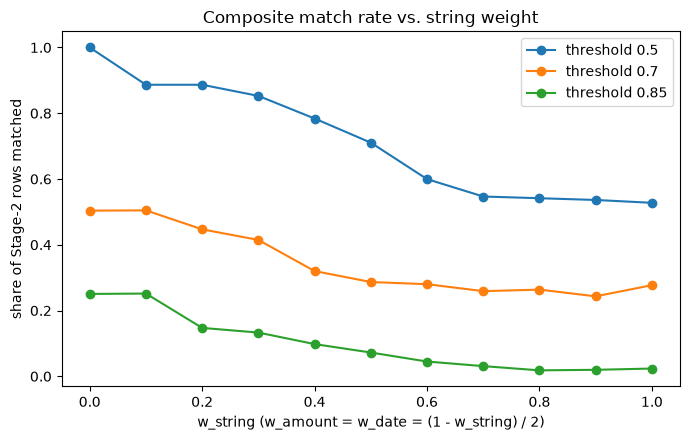

In [21]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for t, grp in composite_sweep_df.groupby("threshold"):
    ax.plot(grp["w_string"], grp["match_rate"], marker="o", label=f"threshold {t}")
ax.set_xlabel("w_string (w_amount = w_date = (1 - w_string) / 2)")
ax.set_ylabel("share of Stage-2 rows matched")
ax.set_title("Composite match rate vs. string weight")
ax.legend()
plt.tight_layout()
plt.show()

**Finding.** Match rate falls as `w_string` rises and climbs back toward
the pure-string numbers from Section 5 only at `w_string = 1.0` (the two
should - and do - agree: at threshold 0.70, `w_string = 1.0` gives 27.7%,
identical to Section 5/8's `partial_ratio >= 70` result, which is exactly
what a composite that's *all* string weight should reduce to). At
`w_string = 0`, threshold 0.50 clears 100% of Stage-2 rows - mechanically
guaranteed, since the minimum possible composite there is `0.5*1 +
0.5*0 = 0.5` (amount_score is always 1, date_score is never negative), so
the baseline result from above is really the `w_string = 0` corner of this
same sweep. The sweep's real message: coverage is a smooth dial between
"trust the block" and "require good text," not a binary choice - a
moderate blend like `w_amount = w_date = 0.3, w_string = 0.4` at threshold
0.50 clears 78.4% of Stage-2 rows (35.7% of all bank rows), which combined
with Stage 1 puts total blind coverage at ~89.6% - a middle point that
still requires *some* text corroboration rather than trusting blocking
blindly.

In [22]:
# Does ranking by composite (not string alone) actually change which
# candidate wins, where it matters - the 195 Stage-2 rows with 2+
# candidates (block_size == 1 rows have no second candidate to rank against)?
multi_ids = stage2_block_size[stage2_block_size >= 2].index
multi_df = remaining_df[remaining_df["bank_txn_id"].isin(multi_ids)]

string_pick = composite_best(multi_df, 0, 0, 1).rename(columns={"best_header": "string_pick"})
composite_pick = composite_best(multi_df, 1/3, 1/3, 1/3).rename(columns={"best_header": "composite_pick"})
pick_compare = string_pick[["bank_txn_id", "string_pick"]].merge(
    composite_pick[["bank_txn_id", "composite_pick"]], on="bank_txn_id"
)
flips = pick_compare["string_pick"] != pick_compare["composite_pick"]
print(f"{len(pick_compare)} multi-candidate Stage-2 rows")
print(f"composite (equal weights) picks a different candidate than string-only in "
      f"{flips.sum()} of them ({flips.mean():.1%})")

195 multi-candidate Stage-2 rows
composite (equal weights) picks a different candidate than string-only in 95 of them (48.7%)


**Finding.** Among the 195 rows where a ranking choice actually matters
(2+ candidates in the block), equal-weight composite disagrees with
pure-string ranking on 95 of them (48.7%) - almost a coin flip. Date
proximity is doing real work here: when two same-amount, same-window
candidates both have weak/similar text scores (again, no counterparty on
the ledger side to match against), the closer-in-time one is a genuinely
better tie-breaker than whichever happens to score one rapidfuzz point
higher on a truncated label. This is a small population (195 of 52,988
bank rows) but it's exactly the case "rank by composite, not string alone"
was meant to fix, and it does.

## 11. Where this leaves the reconciliation scoreboard

Four numbers, same population basis (percent of all 52,988 bank rows),
for comparison:

In [23]:
# Pull the "moderate blend" row straight from the sweep computed above,
# rather than re-typing a number - w_string=0.4 means w_amount=w_date=0.3.
moderate_rate = composite_sweep_df.loc[
    (composite_sweep_df["w_string"] == 0.4) & (composite_sweep_df["threshold"] == 0.50),
    "match_rate",
].iloc[0]
n_moderate = round(moderate_rate * n_stage2)

je_rate = n_je / n_all

# Each Stage-2 method is an ALTERNATIVE, not additive with the others -
# so "total" pairs each one with Stage 1 separately, not a running cumsum.
final_compare = pd.DataFrame([
    {"method": "Stage 1 - JE number (always applied first)",
     "n": n_je, "pct_of_all": je_rate, "total_with_stage_1": je_rate},
    {"method": "+ Stage 2: string-only (partial_ratio >= 70, Sec. 8)",
     "n": n_fuzzy, "pct_of_all": n_fuzzy / n_all, "total_with_stage_1": je_rate + n_fuzzy / n_all},
    {"method": "+ Stage 2: composite (w_amount=w_date=0.3, w_string=0.4, t=0.50)",
     "n": n_moderate, "pct_of_all": n_moderate / n_all, "total_with_stage_1": je_rate + n_moderate / n_all},
    {"method": "+ Stage 2: baseline (unique block, exact amount, ignore text)",
     "n": len(baseline_matched), "pct_of_all": len(baseline_matched) / n_all,
     "total_with_stage_1": je_rate + len(baseline_matched) / n_all},
])
final_compare

,method,n,pct_of_all,total_with_stage_1
0,Stage 1 - JE number (always applied first),28546,0.538726,0.538726
1,"+ Stage 2: string-only (partial_ratio >= 70, S...",6684,0.126142,0.664868
2,"+ Stage 2: composite (w_amount=w_date=0.3, w_s...",18914,0.356949,0.895674
3,"+ Stage 2: baseline (unique block, exact amoun...",23931,0.451631,0.990356


**Finding.** The honest recommendation isn't "use the baseline because
it scores highest" - it's 99% because this dataset's amounts are a perfect
mirror, not because unique-block-membership is generally trustworthy.
The composite score is the right production default: it keeps text as a
real check (so a coincidental same-amount, same-window bank row without
*any* plausible textual resemblance to its block-mate still has to clear a
bar), while no longer discarding the amount/date signal blocking already
computed. Where to sit on the `w_string` dial is a judgment call between
coverage and false-positive risk that - per the Hard rules on detectability
tiers - is exactly the kind of thing Phase 5's scoring against
`ground_truth.error_type = 'unmatched_bank'` should settle with real
precision/recall, not a blind guess. This notebook stays blind on purpose
and stops here.